In [1]:
print("Setup complete")

Setup complete


In [2]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt

print("All libraries working")

All libraries working


In [3]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.drop('customerID', axis=1, inplace=True)

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [6]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
df = df.dropna()

In [8]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

In [10]:
def tenure_group(tenure):
    if tenure <= 12:
        return '0-1 Year'
    elif tenure <= 24:
        return '1-2 Years'
    elif tenure <= 48:
        return '2-4 Years'
    elif tenure <= 60:
        return '4-5 Years'
    else:
        return '5+ Years'

df['tenure_group'] = df['tenure'].apply(tenure_group)

In [11]:
cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

for col in cols:
    df[col] = df[col].replace({'No internet service': 'No'})

In [12]:
df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})

In [13]:
yes_no_cols = [
    'Partner','Dependents','PhoneService',
    'MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV',
    'StreamingMovies','PaperlessBilling'
]

for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [14]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [15]:
df.head()
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   int64  
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   int64  
 9   OnlineBackup      7032 non-null   int64  
 10  DeviceProtection  7032 non-null   int64  
 11  TechSupport       7032 non-null   int64  
 12  StreamingTV       7032 non-null   int64  
 13  StreamingMovies   7032 non-null   int64  
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

In [16]:
df = pd.get_dummies(df, drop_first=True)

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   MultipleLines                          7032 non-null   int64  
 7   OnlineSecurity                         7032 non-null   int64  
 8   OnlineBackup                           7032 non-null   int64  
 9   DeviceProtection                       7032 non-null   int64  
 10  TechSupport                            7032 non-null   int64  
 11  StreamingTV         

In [18]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

C:\Users\nikha\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7910447761194029
[[933 100]
 [194 180]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [28]:
y_prob = model.predict_proba(X_test)[:, 1]

In [29]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("AUC-ROC:", auc)

AUC-ROC: 0.8302669655383055


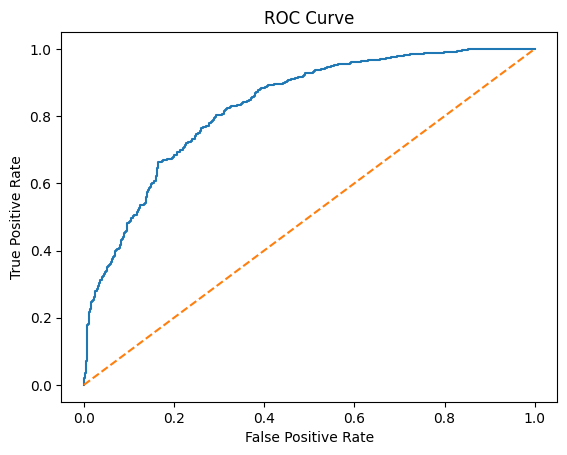

In [30]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [31]:
y_pred_custom = (y_prob > 0.3).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1033
           1       0.51      0.75      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.76      1407



In [32]:
!pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 7.4 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   -- ------------------------------------- 2.6/38.1 MB 13.9 MB/s eta 0:00:03
   ---- ----------------------------------- 4.7/38.1 MB 12.3 MB/s eta 0:00:03
   ------- -------------------------------- 7.3/38.1 MB 12.5 MB/s eta 0:00:03
   ---------- ----------------------------- 10.5/38.1 MB 12.6 MB/s eta 0:00:03
   -------------- ------------------------- 13.4/38.1 MB 12.9 MB/s eta 0:00:02
   ----------------- ---------------------- 16.3/38.1 MB 13.1 MB/s eta 0:00:02
   -------------------- ------------------- 19.4/38.1 MB 13.2 MB/s eta 0:00:02
   ----------------------- ---------------- 22.3/38.1 MB 13.5 MB/s eta 0:00:02
   -------------------------- ------------- 24.9/38.1 MB 13.3 MB/s eta 0:00:01
   ----------------------------- ---------- 28.0/38.1 MB 13.3 MB/s eta 0:0

In [33]:
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

C:\Users\nikha\miniforge3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TypeError: loop of ufunc does not support argument 0 of type float which has no callable rint method

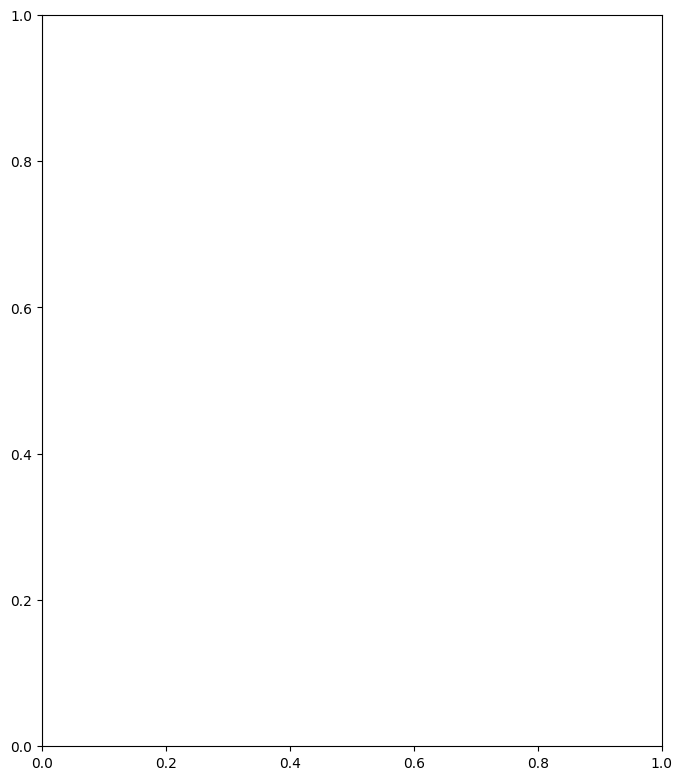

In [34]:
shap.summary_plot(shap_values, X_test)

In [ ]:
shap.plots.waterfall(shap_values[0])

TypeError: loop of ufunc does not support argument 0 of type float which has no callable rint method

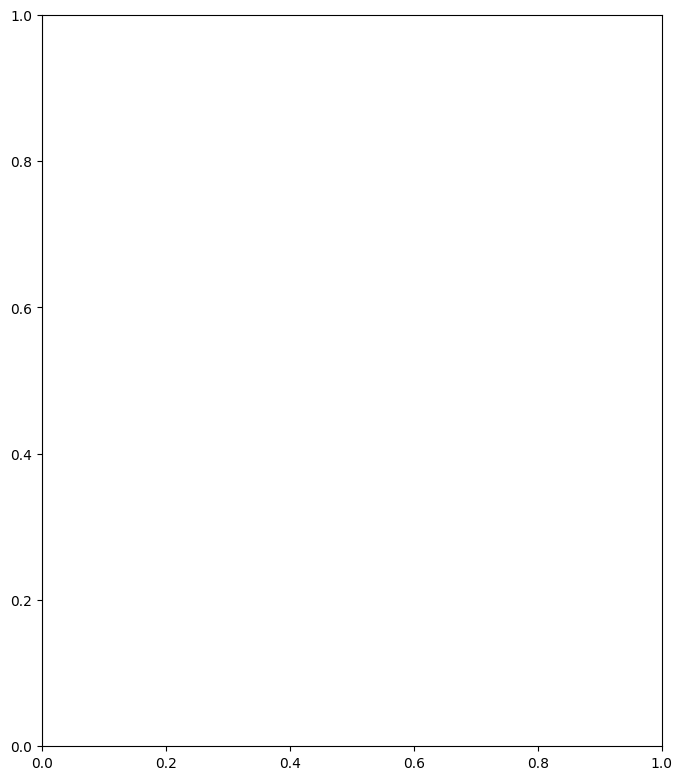

In [35]:
shap.summary_plot(shap_values, X_test)

TypeError: loop of ufunc does not support argument 0 of type float which has no callable rint method

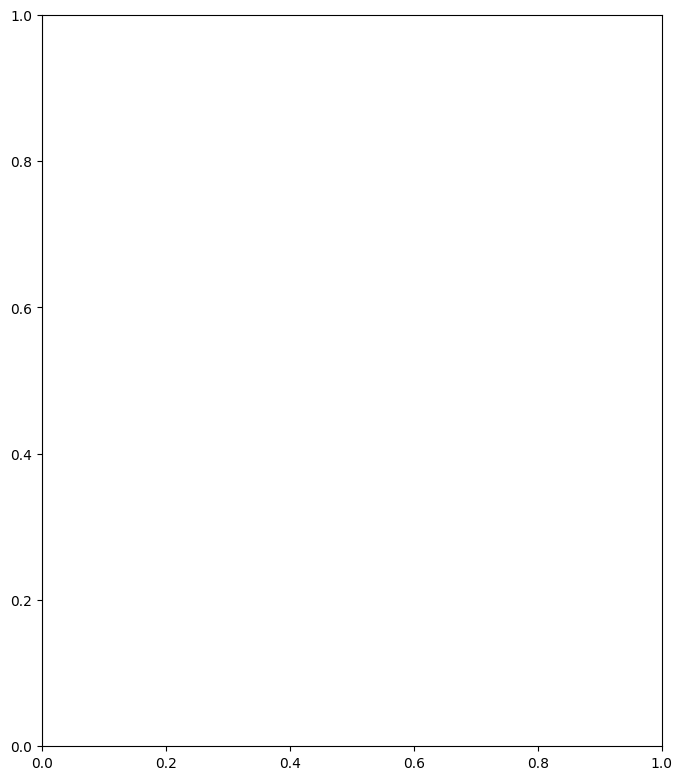

In [36]:
shap.summary_plot(shap_values.values, X_test)

TypeError: loop of ufunc does not support argument 0 of type float which has no callable rint method

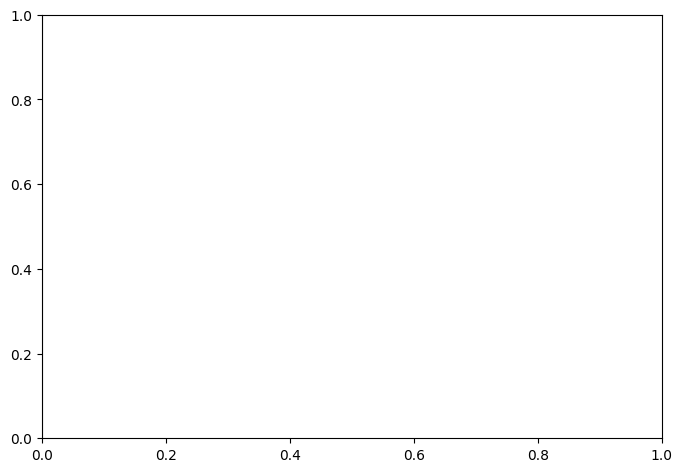

In [37]:
shap.plots.beeswarm(shap_values)

In [38]:
X_train.dtypes

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                   float64
PhoneService                               int64
MultipleLines                              int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
InternetService_Fiber optic                 bool
InternetService_No                          bool
Contract_One year                           bool
Contract_Two year                           bool
PaymentMethod_Credit

In [39]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [40]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [41]:
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

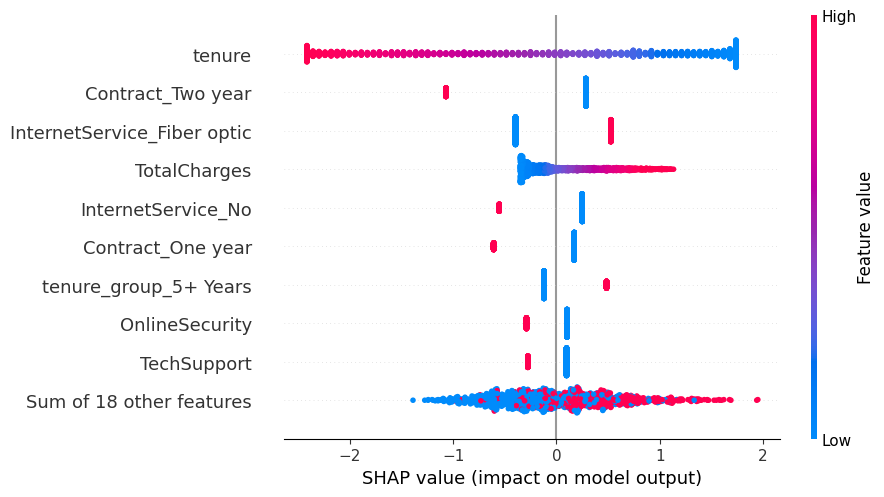

In [42]:
shap.plots.beeswarm(shap_values)

In [43]:
import pandas as pd

results = X_test.copy()
results['Actual_Churn'] = y_test.values
results['Predicted_Churn'] = y_pred_custom
results['Churn_Probability'] = y_prob

In [44]:
import numpy as np

feature_names = X_test.columns

def get_top_features(shap_values_row, feature_names, top_n=3):
    indices = np.argsort(np.abs(shap_values_row))[-top_n:]
    return [feature_names[i] for i in indices]

top_features = []

for i in range(len(shap_values.values)):
    top_features.append(get_top_features(shap_values.values[i], feature_names))

results['Top_Drivers'] = top_features

In [45]:
results.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2 Years,tenure_group_2-4 Years,tenure_group_4-5 Years,tenure_group_5+ Years,Actual_Churn,Predicted_Churn,Churn_Probability,Top_Drivers
2481,1.0,1.0,1.0,0.0,1.168321,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0.009858,"[InternetService_No, Contract_Two year, tenure]"
6784,0.0,0.0,0.0,0.0,-0.543522,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0,0,0.095385,"[InternetService_Fiber optic, InternetService_..."
6125,1.0,0.0,1.0,0.0,-0.788071,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1,1,0.642863,"[tenure_group_1-2 Years, InternetService_Fiber..."
3052,1.0,0.0,1.0,0.0,0.190125,1.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0,0,0.112079,"[OnlineSecurity, tenure, InternetService_Fiber..."
4099,0.0,0.0,0.0,0.0,-1.073378,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0.366490,"[InternetService_Fiber optic, PhoneService, te..."


In [46]:
def explain_churn(row):
    drivers = ", ".join(row['Top_Drivers'])
    return f"Customer likely to churn due to {drivers}"

results['Explanation'] = results.apply(explain_churn, axis=1)

In [47]:
def clean_feature_name(feature):
    mapping = {
        'tenure': 'low tenure',
        'MonthlyCharges': 'high monthly charges',
        'TotalCharges': 'low lifetime value',
        'Contract_Two year': 'long-term contract',
        'Contract_One year': 'annual contract',
        'InternetService_Fiber optic': 'fiber internet service',
        'InternetService_No': 'no internet service',
        'OnlineSecurity': 'no online security',
        'TechSupport': 'lack of tech support',
        'PaperlessBilling': 'paperless billing',
    }
    
    return mapping.get(feature, feature)

In [48]:
def clean_drivers(driver_list):
    return [clean_feature_name(f) for f in driver_list]

results['Top_Drivers_Clean'] = results['Top_Drivers'].apply(clean_drivers)

In [49]:
def explain_churn(row):
    drivers = ", ".join(row['Top_Drivers_Clean'])
    
    if row['Predicted_Churn'] == 1:
        return f"Customer is likely to churn due to {drivers}."
    else:
        return f"Customer is likely to stay due to {drivers}."

results['Explanation'] = results.apply(explain_churn, axis=1)

In [50]:
results[['Churn_Probability', 'Top_Drivers_Clean', 'Explanation']].head()

,Churn_Probability,Top_Drivers_Clean,Explanation
2481,0.009858,"[no internet service, long-term contract, low ...",Customer is likely to stay due to no internet ...
6784,0.095385,"[fiber internet service, no internet service, ...",Customer is likely to stay due to fiber intern...
6125,0.642863,"[tenure_group_1-2 Years, fiber internet servic...",Customer is likely to churn due to tenure_grou...
3052,0.112079,"[no online security, low tenure, fiber interne...",Customer is likely to stay due to no online se...
4099,0.366490,"[fiber internet service, PhoneService, low ten...",Customer is likely to churn due to fiber inter...


In [51]:
results.to_csv("churn_predictions_explained.csv", index=False)

In [52]:
def clean_feature_name(feature):
    mapping = {
        'tenure': 'low tenure',
        'tenure_group_1-2 Years': 'new customer tenure',
        'tenure_group_2-4 Years': 'mid-term tenure',
        'tenure_group_5+ Years': 'long customer history',

        'MonthlyCharges': 'high monthly charges',
        'TotalCharges': 'low lifetime value',

        'Contract_Two year': 'long-term contract',
        'Contract_One year': 'annual contract',

        'InternetService_Fiber optic': 'fiber internet service',
        'InternetService_No': 'no internet service',

        'OnlineSecurity': 'no online security',
        'TechSupport': 'lack of tech support',

        'PaperlessBilling': 'paperless billing',
        'PhoneService': 'phone service usage'
    }

    return mapping.get(feature, feature)

In [53]:
def explain_churn(row):
    drivers = ", ".join(row['Top_Drivers_Clean'])

    if row['Predicted_Churn'] == 1:
        return f"High churn risk driven by {drivers}."
    else:
        return f"Low churn risk due to {drivers}."

In [54]:
def risk_bucket(prob):
    if prob > 0.7:
        return "High Risk"
    elif prob > 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

results['Risk_Level'] = results['Churn_Probability'].apply(risk_bucket)

In [55]:
results.to_csv("churn_final_output.csv", index=False)

In [56]:
# Step 1: Keep only business-friendly columns
final_df = results[[
    'Churn_Probability',
    'Risk_Level',
    'Actual_Churn',
    'Predicted_Churn',
    'Top_Drivers_Clean',
    'Explanation'
]].copy()

# Step 2: Convert list → clean string
final_df['Top_Drivers'] = final_df['Top_Drivers_Clean'].apply(lambda x: ", ".join(x))

# Step 3: Drop old list column
final_df = final_df.drop(columns=['Top_Drivers_Clean'])

# Step 4: Rename columns (important for presentation)
final_df.columns = [
    'Churn Probability',
    'Risk Level',
    'Actual Churn',
    'Predicted Churn',
    'Explanation',
    'Top Drivers'
]

# Step 5: Export clean CSV
final_df.to_csv("churn_dashboard_ready.csv", index=False)

In [57]:
final_df.to_csv(
    "churn_dashboard_ready.csv",
    index=False,
    encoding='utf-8-sig'
)

In [58]:
import ollama

ModuleNotFoundError: No module named 'ollama'

In [1]:
import sys
!{sys.executable} -m pip install ollama

  Using cached ollama-0.6.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached pydantic-2.13.3-py3-none-any.whl.metadata (108 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.46.3-cp313-cp313-win_amd64.whl.metadata (6.7 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached ollama-0.6.1-py3-none-any.whl (14 kB)
Using cached pydantic-2.13.3-py3-none-any.whl (471 kB)
Using cached pydantic_core-2.46.3-cp313-cp313-win_amd64.whl (2.1 MB)
Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)
Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)

   -------- ------------------------------- 1/5 [pydantic-core]
   ---------------- ----------------------- 2/5 [annotated-types]
   ------------------------ --------------- 3/5 [pydantic]
   ------------------------ --------------- 3/5 [pydantic]
   ------------------------ --------------- 3/5 [pydantic]
   ------------------------ -------------

In [1]:
import ollama

In [2]:
response = ollama.chat(
    model='tinyllama',
    messages=[{"role": "user", "content": "Explain customer churn in one short sentence."}]
)

print(response['message']['content'])

Customer churn, or the occurrence of customers leaving a company due to unresolved issues and/or dissatisfaction with its services/products, can negatively impact the growth and profitability of an organization. When a customer has a negative experience or perceives a lack of value from a product or service, they may choose to move on to another vendor or brand that offers better value and better service.


In [3]:
def generate_llm_explanation(prob, risk, drivers):
    prompt = f"""
    Customer churn probability: {prob}
    Risk level: {risk}
    Top drivers: {drivers}

    Give output strictly in this format:
    Reason: <1 short business sentence>
    Action: <1 short retention recommendation>
    """

    response = ollama.chat(
        model='tinyllama',
        messages=[{"role": "user", "content": prompt}]
    )

    return response['message']['content']

In [4]:
generate_llm_explanation(
    0.85,
    "High Risk",
    "low tenure, low lifetime value, fiber internet service"
)

'To summarize the customer churn probability of our artificial intelligence assistant and the risks associated with it, the following text format would be appropriate:\n\nCustomer Churn Probability: 0.85\nRisk Level: High Risks\nTop Drivers: Low Tenure, Low Lifetime Value, Fiber Internet Service\nAction Recommendation: Given the given text in this format, the following retention recommendations would apply:\n- Customers with low tenure and low lifetime value will be at increased risk for churn. This customer group is most likely to experience issues related to the quality of service provided, high equipment maintenance requirements, or poor user interface design. As a result, we strongly encourage these customers to consider alternatives that offer better value for their money. - Fiber internet service is considered a top driver of customer satisfaction. Customers who can access this service will likely find it easy and reliable, providing them with peace of mind about their internet e

In [5]:
def generate_llm_explanation(prob, risk, drivers):
    prompt = f"""
    You are a business analyst.

    Customer churn probability: {prob}
    Risk level: {risk}
    Top drivers: {drivers}

    STRICT RULES:
    - Only 2 lines output
    - No extra explanation
    - No paragraphs

    FORMAT:
    Reason: <one short sentence>
    Action: <one short recommendation>
    """

    response = ollama.chat(
        model='tinyllama',
        messages=[{"role": "user", "content": prompt}]
    )

    return response['message']['content']

In [6]:
generate_llm_explanation(
    0.85,
    "High Risk",
    "low tenure, low lifetime value, fiber internet service"
)

"Business Analyst: Hi there! We are an innovative tech company focused on providing the most reliable and efficient services to our customers. Our customer satisfaction rate has been consistently high, which has contributed greatly to our success. However, we understand that there are some customers who may be unhappy with their service due to factors beyond our control, and we want to mitigate this risk as much as possible.\n\nCustomer Churn Probability: According to industry data, the probability of customer churn is high for low-tenure, low lifetime value customers in our niche. This indicates that we should take proactive measures to prevent churn for these customers.\n\nRisk Level: We are classified as a High Risk customer due to our commitment to providing top-notch services at an affordable price point. With this in mind, we must ensure that we offer appropriate solutions and support to prevent further dissatisfaction among this group of customers.\n\nTop Drivers: Low Tenure: In

In [7]:
final_df['Explanation'] = final_df.apply(
    lambda row: generate_llm_explanation(
        row['Churn Probability'],
        row['Risk Level'],
        row['Top Drivers']
    ),
    axis=1
)

NameError: name 'final_df' is not defined

In [8]:
import pandas as pd

final_df = pd.read_csv("churn_dashboard_ready.csv")

In [9]:
final_df.head()

,Churn Probability,Risk Level,Actual Churn,Predicted Churn,Explanation,Top Drivers
0,0.009858,Low Risk,0,0,Customer is likely to stay due to no internet ...,"no internet service, long-term contract, low t..."
1,0.095385,Low Risk,0,0,Customer is likely to stay due to fiber intern...,"fiber internet service, no internet service, l..."
2,0.642863,Medium Risk,1,1,Customer is likely to churn due to tenure_grou...,"tenure_group_1-2 Years, fiber internet service..."
3,0.112079,Low Risk,0,0,Customer is likely to stay due to no online se...,"no online security, low tenure, fiber internet..."
4,0.366490,Low Risk,0,1,Customer is likely to churn due to fiber inter...,"fiber internet service, PhoneService, low tenure"


In [10]:
final_df['Explanation'] = final_df.apply(
    lambda row: generate_llm_explanation(
        row['Churn Probability'],
        row['Risk Level'],
        row['Top Drivers']
    ),
    axis=1
)


KeyboardInterrupt



KeyboardInterrupt: 

In [ ]:
final_df.apply(...)

In [ ]:
sample_df = final_df.head(10)

sample_df['Explanation'] = sample_df.apply(
    lambda row: generate_llm_explanation(
        row['Churn Probability'],
        row['Risk Level'],
        row['Top Drivers']
    ),
    axis=1
)

In [ ]:
cache = {}

def generate_fast(prob, risk, drivers):
    key = (risk, drivers)

    if key in cache:
        return cache[key]

    result = generate_llm_explanation(prob, risk, drivers)
    cache[key] = result
    return result

In [ ]:
sample_df['Explanation'] = sample_df.apply(
    lambda row: generate_fast(
        row['Churn Probability'],
        row['Risk Level'],
        row['Top Drivers']
    ),
    axis=1
)

In [ ]:
final_df['LLM Explanation'] = final_df.apply(
    lambda row: generate_fast(
        row['Churn Probability'],
        row['Risk Level'],
        row['Top Drivers']
    ),
    axis=1
)

In [ ]:
final_df.to_csv("churn_dashboard_with_llm.csv", index=False, encoding="utf-8-sig")

In [11]:
sample_df = final_df.head(50).copy()

cache = {}

sample_df['LLM Explanation'] = sample_df.apply(
    lambda row: generate_fast(
        row['Churn Probability'],
        row['Risk Level'],
        row['Top Drivers']
    ),
    axis=1
)

sample_df.to_csv("churn_dashboard_with_llm_sample.csv", index=False, encoding="utf-8-sig")

NameError: name 'generate_fast' is not defined

In [12]:
import pandas as pd
import ollama

In [13]:
final_df = pd.read_csv("churn_dashboard_ready.csv")
final_df.head()

,Churn Probability,Risk Level,Actual Churn,Predicted Churn,Explanation,Top Drivers
0,0.009858,Low Risk,0,0,Customer is likely to stay due to no internet ...,"no internet service, long-term contract, low t..."
1,0.095385,Low Risk,0,0,Customer is likely to stay due to fiber intern...,"fiber internet service, no internet service, l..."
2,0.642863,Medium Risk,1,1,Customer is likely to churn due to tenure_grou...,"tenure_group_1-2 Years, fiber internet service..."
3,0.112079,Low Risk,0,0,Customer is likely to stay due to no online se...,"no online security, low tenure, fiber internet..."
4,0.366490,Low Risk,0,1,Customer is likely to churn due to fiber inter...,"fiber internet service, PhoneService, low tenure"


In [14]:
def generate_fast(prob, risk, drivers):
    key = (risk, drivers)

    if key in cache:
        return cache[key]

    result = generate_llm_explanation(prob, risk, drivers)
    cache[key] = result
    return result

In [15]:
sample_df = final_df.head(50).copy()

cache = {}

sample_df['LLM Explanation'] = sample_df.apply(
    lambda row: generate_fast(
        row['Churn Probability'],
        row['Risk Level'],
        row['Top Drivers']
    ),
    axis=1
)

sample_df.to_csv("churn_dashboard_with_llm_sample.csv", index=False, encoding="utf-8-sig")

In [16]:
churn_dashboard_with_llm_sample.csv

NameError: name 'churn_dashboard_with_llm_sample' is not defined

In [17]:
sample_df.to_csv("churn_dashboard_with_llm_sample.csv", index=False, encoding="utf-8-sig")

In [18]:
def generate_llm_explanation(prob, risk, drivers):
    prompt = f"""
Customer churn probability: {prob}
Risk level: {risk}
Drivers: {drivers}

STRICT RULES:
- Only 2 lines output
- No paragraphs
- No introductions
- No explanations
- No extra text

FORMAT:
Reason: <one short sentence>
Action: <one short recommendation>
"""

    response = ollama.chat(
        model='tinyllama',
        messages=[{"role": "user", "content": prompt}]
    )

    return response['message']['content']

In [19]:
model='mistral'

In [20]:
sample_df['LLM Explanation'] = sample_df.apply(...)

AssertionError: 

In [21]:
sample_df['LLM Explanation'] = sample_df.apply(...)

AssertionError: 

In [ ]:
sample_df['LLM Explanation'] = sample_df.apply(
    lambda row: generate_fast(
        row['Churn Probability'],
        row['Risk Level'],
        row['Top Drivers']
    ),
    axis=1
)

In [22]:
sample_df['LLM Explanation'] = sample_df.apply(
    lambda row: generate_fast(
        row['Churn Probability'],
        row['Risk Level'],
        row['Top Drivers']
    ),
    axis=1
)

sample_df.to_csv("churn_dashboard_with_llm_sample.csv", index=False, encoding="utf-8-sig")

In [23]:
def generate_llm_explanation(prob, risk, drivers):
    prompt = f"""
Customer churn probability: {prob}
Risk level: {risk}
Drivers: {drivers}

Respond ONLY with:
Reason: one short sentence
Action: one short recommendation
"""

    response = ollama.chat(
        model='tinyllama',
        messages=[{"role": "user", "content": prompt}]
    )

    text = response['message']['content']

    # 🔥 CLEANUP (removes garbage output)
    lines = text.split("\n")
    clean_lines = [l for l in lines if l.startswith("Reason") or l.startswith("Action")]

    return "\n".join(clean_lines)

In [24]:
sample_df['LLM Explanation'] = sample_df.apply(
    lambda row: generate_llm_explanation(
        row['Churn Probability'],
        row['Risk Level'],
        row['Top Drivers']
    ),
    axis=1
)

In [25]:
sample_df.to_csv("churn_dashboard_with_llm_sample.csv", index=False)

In [26]:
def generate_llm_explanation(prob, risk, drivers):
    prompt = f"""
Customer churn probability: {prob}
Risk level: {risk}
Drivers: {drivers}

Respond ONLY with:
Reason: one short sentence
Action: one short recommendation
"""

    response = ollama.chat(
        model='tinyllama',
        messages=[{"role": "user", "content": prompt}]
    )

    text = response['message']['content']

    # 🔥 CLEANUP (removes garbage output)
    lines = text.split("\n")
    clean_lines = [l for l in lines if l.startswith("Reason") or l.startswith("Action")]

    return "\n".join(clean_lines)

In [27]:
sample_df['LLM Explanation'] = sample_df.apply(
    lambda row: generate_llm_explanation(
        row['Churn Probability'],
        row['Risk Level'],
        row['Top Drivers']
    ),
    axis=1
)

In [28]:
sample_df.to_csv("churn_dashboard_with_llm_sample.csv", index=False)

In [29]:
# clean LLM text first
sample_df['LLM Explanation'] = (
    sample_df['LLM Explanation']
    .astype(str)
    .str.replace('\n', ' ', regex=False)
    .str.replace('\r', ' ', regex=False)
)

# export as Excel, not CSV
sample_df.to_excel("churn_dashboard_with_llm_sample.xlsx", index=False)

ModuleNotFoundError: No module named 'openpyxl'

In [30]:
!pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy

In [31]:
sample_df.to_excel("churn_dashboard_with_llm_sample.xlsx", index=False)

In [32]:
def clean_ai_explanation(row):
    prob = row['Churn Probability']
    risk = row['Risk Level']
    drivers = row['Top Drivers']

    if risk == "High Risk":
        action = "Prioritize immediate retention outreach with a targeted offer or support intervention."
    elif risk == "Medium Risk":
        action = "Monitor closely and send proactive engagement or service improvement communication."
    else:
        action = "Maintain regular engagement and continue standard customer support."

    return f"Reason: Customer is classified as {risk.lower()} with churn probability {prob:.2f}, mainly driven by {drivers}. Action: {action}"

sample_df['LLM Explanation'] = sample_df.apply(clean_ai_explanation, axis=1)

sample_df.to_excel("churn_dashboard_with_llm_sample.xlsx", index=False)

In [33]:
import pandas as pd
import ollama

# unique patterns only
patterns = (
    final_df[['Risk Level', 'Top Drivers']]
    .drop_duplicates()
    .reset_index(drop=True)
)

def generate_pattern_explanation(risk, drivers):
    prompt = f"""
Risk level: {risk}
Top churn drivers: {drivers}

Write only this format:
Reason: <one short business reason>
Action: <one short retention action>
"""

    response = ollama.chat(
        model='tinyllama',
        messages=[{"role": "user", "content": prompt}]
    )

    return response['message']['content'].strip()

patterns['AI Explanation'] = patterns.apply(
    lambda row: generate_pattern_explanation(
        row['Risk Level'],
        row['Top Drivers']
    ),
    axis=1
)

final_df = final_df.merge(
    patterns,
    on=['Risk Level', 'Top Drivers'],
    how='left'
)

final_df.to_excel("churn_dashboard_ai_enhanced.xlsx", index=False)